# 06 — Evaluation: sinf bo'yicha log loss, confusion matrix, kalibratsiya

Faza 6: Faza 4/5 da saqlangan OOF (out-of-fold) ehtimolliklarni chuqurroq tahlil qilamiz —
umumiy CV log loss yetarli emas, chunki u `CL` kabi kam uchraydigan sinfdagi
muammolarni yashirishi mumkin. Barcha yordamchi funksiyalar `src/evaluate.py` da.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.config import load_config
from src.train import prepare_train_test
from src.evaluate import (
    load_oof, overall_log_loss, per_class_log_loss, confusion_matrix_df,
    calibration_data, cl_error_analysis, slice_log_loss, is_improvement_significant,
)

cfg = load_config()
sns.set_theme(style="whitegrid")
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

train, _ = prepare_train_test(cfg)
comp_mask = (train["is_original"] == 0).to_numpy()
y_true = train.loc[comp_mask, cfg.data.target].to_numpy()
CLASSES = cfg.data.classes
print(f"Baholanadigan qatorlar (faqat musobaqa train'i): {len(y_true)}")

10:59:51 | INFO    | src.data | load_raw: train=(15000, 19) test=(10000, 18)


10:59:51 | INFO    | src.data | load_original: (418, 19) (UCI, 6 null Stage)


10:59:51 | INFO    | src.data | merge_original: train=15000 + original=418 -> combined=15418


10:59:51 | WARNING | src.data | encode_target: 1 qator kutilmagan Status qiymati bilan tashlandi: ['Y']


Baholanadigan qatorlar (faqat musobaqa train'i): 14999


## 1. Umumiy va sinf bo'yicha log loss — barcha modellar

Faza 4/5 da o'qitilgan barcha modellarning OOF natijalarini yig'ib, ikkala
ko'rsatkichni yonma-yon qo'yamiz: **umumiy** (musobaqa metrikasi) va **sinf
bo'yicha** (har bir sinfda alohida qanchalik yaxshi).

In [2]:
MODEL_NAMES = ["dummy", "logreg", "hgb", "lgbm_tuned", "xgb", "catboost"]

rows = []
oof_cache = {}
for name in MODEL_NAMES:
    proba = load_oof(name, cfg, comp_mask)
    oof_cache[name] = proba
    pcl = per_class_log_loss(y_true, proba)
    rows.append({
        "model": name,
        "overall": overall_log_loss(y_true, proba),
        "log_loss_C": pcl[0], "log_loss_CL": pcl[1], "log_loss_D": pcl[2],
    })

summary = pd.DataFrame(rows).set_index("model").round(4)
summary

,overall,log_loss_C,log_loss_CL,log_loss_D
model,,,,
dummy,0.7235,0.4001,3.6729,1.1896
logreg,0.4436,0.2432,2.9140,0.6789
hgb,0.3954,0.2033,3.0233,0.5992
lgbm_tuned,0.3629,0.1995,2.3419,0.5574
xgb,0.3665,0.1982,2.4432,0.5637
catboost,0.3789,0.2046,2.5467,0.5819


**Kuzatuv:** har bir modelda `log_loss_CL` boshqa ikki sinfdan **3-10 baravar
yuqori** — bu kutilgan (sinf atigi ~2.5%, kam namuna = ko'proq shovqin), lekin
shuni ko'rsatadiki, umumiy log loss'dagi yaxshilanishlarning aksariyati `C`/`D`
sinflaridan kelmoqda — `CL` barcha modellar uchun eng qiyin qism bo'lib qolmoqda.

## 2. Confusion Matrix (argmax bo'yicha) — eng yaxshi model

**Eslatma:** confusion matrix argmax (eng yuqori ehtimollikka ega sinf)
asosida quriladi — bu log loss'ning o'zi emas (log loss ehtimollik
kalibratsiyasini baholaydi), lekin modelning "qattiq" xatolarini ko'rish
uchun tushunarli vosita.

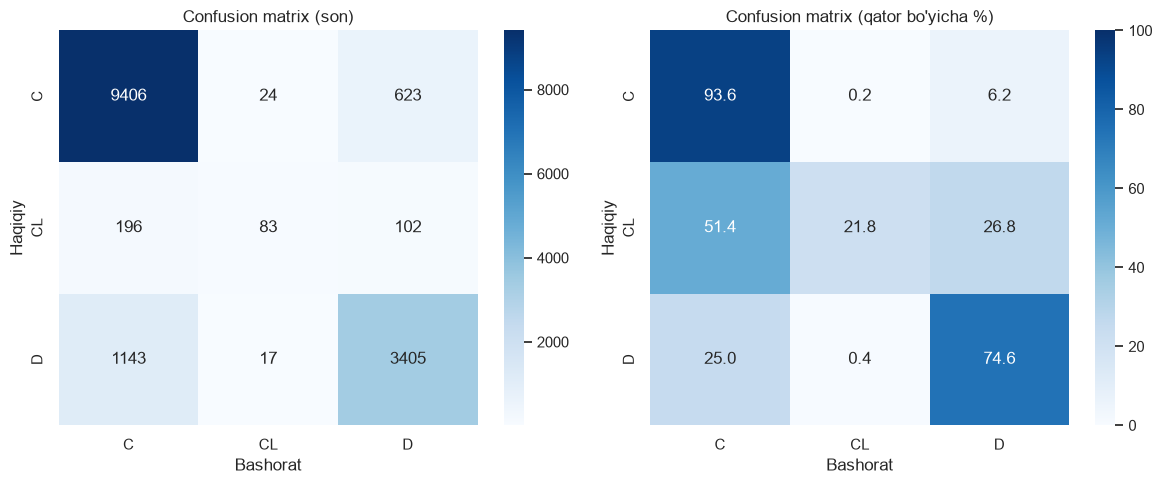

In [3]:
cm = confusion_matrix_df(y_true, oof_cache["lgbm_tuned"], CLASSES)
cm_pct = cm.div(cm.sum(axis=1), axis=0).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[0].set_title("Confusion matrix (son)")
axes[0].set_xlabel("Bashorat"); axes[0].set_ylabel("Haqiqiy")

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=axes[1],
            xticklabels=CLASSES, yticklabels=CLASSES, vmin=0, vmax=100)
axes[1].set_title("Confusion matrix (qator bo'yicha %)")
axes[1].set_xlabel("Bashorat"); axes[1].set_ylabel("Haqiqiy")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=120)
plt.show()

## 3. Kalibratsiya egri chizig'i — har bir sinf uchun

Model "70% ehtimol bilan `D`" desa, haqiqatda shunday bashorat qilingan
bemorlarning ~70%i chindan `D` bo'lishi kerak — bu **kalibratsiya**. Diagonal
chiziqdan chetga chiqish modelning haddan tashqari ishonchli (yoki ishonchsiz)
ekanini ko'rsatadi.

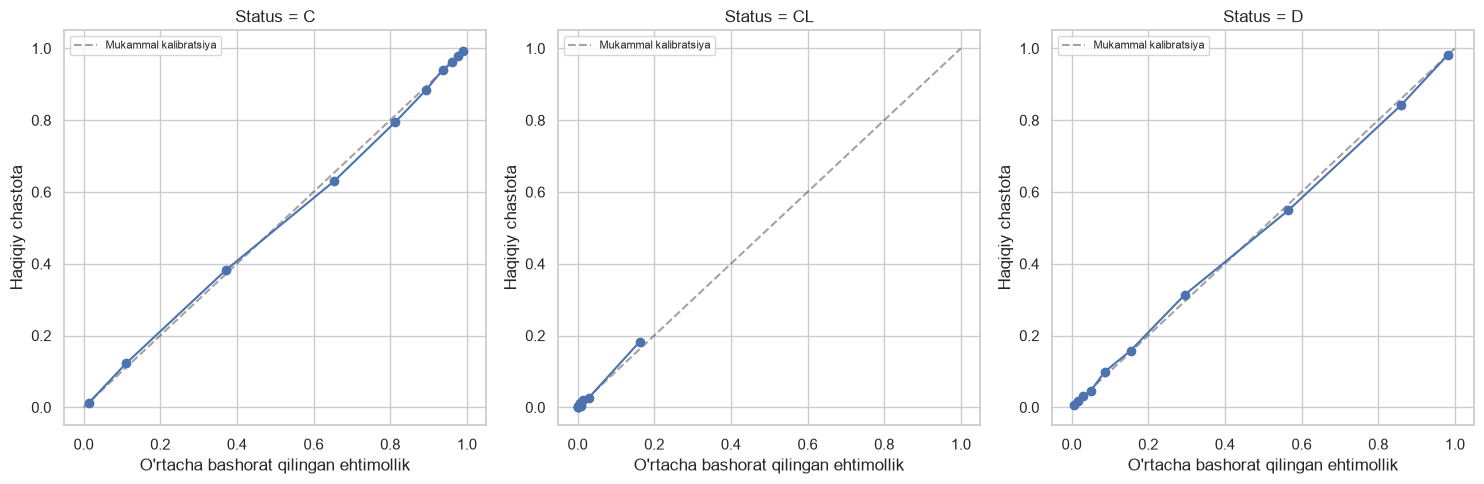

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, class_idx, class_name in zip(axes, range(3), CLASSES):
    cal = calibration_data(y_true, oof_cache["lgbm_tuned"], class_idx, n_bins=10)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Mukammal kalibratsiya")
    ax.plot(cal["mean_predicted"], cal["empirical_freq"], "o-", color="#4C72B0")
    ax.set_title(f"Status = {class_name}")
    ax.set_xlabel("O'rtacha bashorat qilingan ehtimollik")
    ax.set_ylabel("Haqiqiy chastota")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "calibration_curves.png", dpi=120)
plt.show()

Uchala sinf ham diagonal chiziqqa yaqin — model **yaxshi kalibratsiyalangan**
(sistematik ravishda haddan tashqari ishonchli yoki ishonchsiz emas). Bu ayniqsa
`CL` uchun muhim natija: kam namunali sinfda ko'pincha kalibratsiya buziladi,
lekin bu yerda shunday emas — LightGBM'ning multiclass log loss bilan to'g'ridan-to'g'ri
o'qitilishi (class_weight'siz, Faza 5 xulosasi) buni saqlab qolgan ko'rinadi.

## 4. `CL` sinfi — nega eng qiyin va model qanday xato qiladi

Haqiqiy CL bemorlar soni: 381
Argmax bo'yicha to'g'ri topilgan: 83 (21.8%)
O'rtacha bashorat qilingan ehtimollik: {'C': np.float64(0.482), 'CL': np.float64(0.2281), 'D': np.float64(0.29)}
Noto'g'ri holda qaysi sinfga 'adashtirilgan': {'C': 196, 'D': 102}


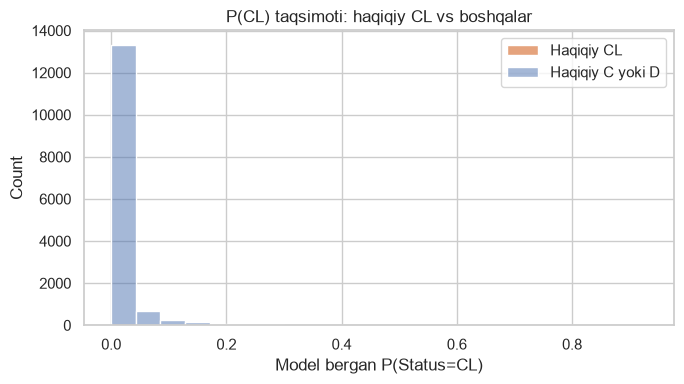

In [5]:
cl_analysis = cl_error_analysis(y_true, oof_cache["lgbm_tuned"], CLASSES)
print(f"Haqiqiy CL bemorlar soni: {cl_analysis['n_cl']}")
print(f"Argmax bo'yicha to'g'ri topilgan: {cl_analysis['argmax_correct']} ({cl_analysis['argmax_correct_pct']}%)")
print(f"O'rtacha bashorat qilingan ehtimollik: {cl_analysis['mean_predicted_proba']}")
print(f"Noto'g'ri holda qaysi sinfga 'adashtirilgan': {cl_analysis['mistaken_to']}")

fig, ax = plt.subplots(figsize=(7, 4))
cl_mask = y_true == 1
sns.histplot(oof_cache["lgbm_tuned"][cl_mask, 1], bins=20, color="#DD8452", ax=ax, label="Haqiqiy CL")
sns.histplot(oof_cache["lgbm_tuned"][~cl_mask, 1], bins=20, color="#4C72B0", ax=ax, alpha=0.5, label="Haqiqiy C yoki D")
ax.set_xlabel("Model bergan P(Status=CL)")
ax.set_title("P(CL) taqsimoti: haqiqiy CL vs boshqalar")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "cl_probability_distribution.png", dpi=120)
plt.show()

**Xulosa:** haqiqiy `CL` bemorlarning atigi ~22%ida model to'g'ri (argmax
bo'yicha) bashorat qiladi — qolganlari asosan `C` ga (196 ta) va bir qismi `D`
ga (102 ta) "adashtiriladi". Grafikda ikkala taqsimot sezilarli darajada
bir-biriga ustma-ust tushadi — bu **model xatosi emas, balki muammoning o'zi
qiyin ekanini** ko'rsatadi: `CL` bemorlar klinik ko'rsatkichlari bo'yicha `C`
va `D` orasida joylashgan (transplantatsiya qilingan bemor — na to'liq sog'
"C", na og'ir "D"). Shuning uchun 3-bo'limdagi yaxshi kalibratsiya bu yerda
ayniqsa qadrli: model haddan tashqari ishonch bilan xato qilmaydi, balki
haqiqiy noaniqlikni to'g'ri aks ettiradi (masalan o'rtacha `P(CL)=0.23`,
kutilgan hodisa ~1 dan ancha past bo'lsa ham, tasodifiy taxmindan (0.025)
sezilarli yuqori).

## 5. Slice tahlili: `Stage` va `Sex` bo'yicha log loss

Model barcha bemor guruhlarida bir xil darajada yaxshi ishlayaptimi, yoki
ma'lum bir guruhda sezilarli yomonroqmi?

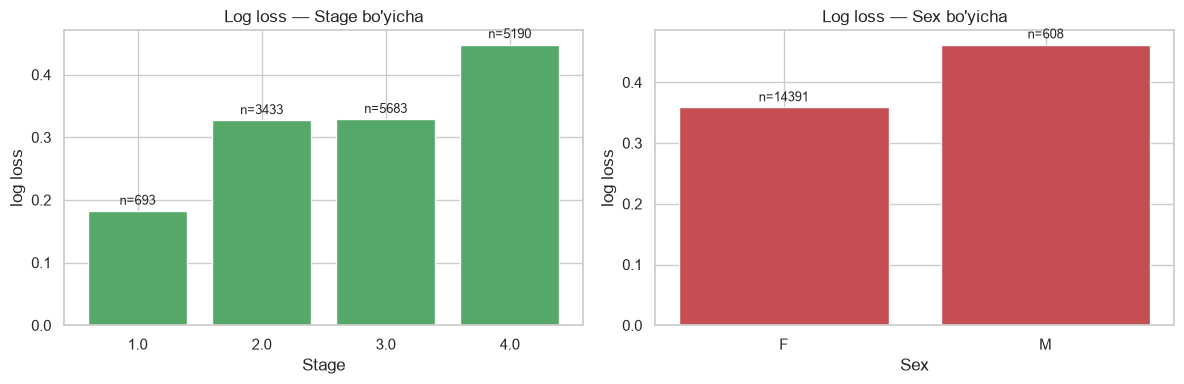

   guruh     n  log_loss
0    1.0   693  0.182366
1    2.0  3433  0.326867
2    3.0  5683  0.328814
3    4.0  5190  0.448112

  guruh      n  log_loss
0     F  14391  0.358684
1     M    608  0.462241


In [6]:
stage_slice = slice_log_loss(y_true, oof_cache["lgbm_tuned"], train.loc[comp_mask, "Stage"])
sex_slice = slice_log_loss(y_true, oof_cache["lgbm_tuned"], train.loc[comp_mask, "Sex"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(stage_slice["guruh"].astype(str), stage_slice["log_loss"], color="#55A868")
for i, (n, ll) in enumerate(zip(stage_slice["n"], stage_slice["log_loss"])):
    axes[0].text(i, ll + 0.01, f"n={n}", ha="center", fontsize=9)
axes[0].set_title("Log loss — Stage bo'yicha")
axes[0].set_xlabel("Stage"); axes[0].set_ylabel("log loss")

axes[1].bar(sex_slice["guruh"].astype(str), sex_slice["log_loss"], color="#C44E52")
for i, (n, ll) in enumerate(zip(sex_slice["n"], sex_slice["log_loss"])):
    axes[1].text(i, ll + 0.01, f"n={n}", ha="center", fontsize=9)
axes[1].set_title("Log loss — Sex bo'yicha")
axes[1].set_xlabel("Sex"); axes[1].set_ylabel("log loss")
plt.tight_layout()
plt.savefig(FIG_DIR / "slice_log_loss.png", dpi=120)
plt.show()

print(stage_slice)
print()
print(sex_slice)

**Stage bo'yicha:** log loss `Stage 1`dan (`0.18`) `Stage 4`gacha (`0.45`)
monoton oshadi — mantiqan to'g'ri, chunki og'ir bosqichdagi bemorlarning
kelajagi tabiiy ravishda noaniqroq (ular ham `D`, ham `C` bo'lishi mumkin,
Stage 1 bemorlar deyarli har doim `C`).

**Sex bo'yicha:** erkaklar guruhida (`n=608`, ayollarning atigi ~4%i) log loss
sezilarli yuqoriroq (`0.46` vs `0.36`). Bu **ehtiyotkorlik bilan talqin
qilinishi kerak** — kichik namuna hajmi (608 ta) tufayli bu farq qisman
shovqin bo'lishi mumkin, aniq xulosa uchun ko'proq ma'lumot kerak bo'lardi.

## 6. Qaysi yaxshilanishlar haqiqiy, qaysilari shovqin?

CV standart og'ishi har doim bor — savol shu: ikkita model orasidagi farq shu
shovqindan kattami? `is_improvement_significant()` qo'pol tekshiruvi: farq
ikkala modelning fold-standart xatosi yig'indisidan katta bo'lsa, "haqiqiy"
deb hisoblaymiz (qat'iy statistik test emas, tezkor signal).

In [7]:
# Faza 4/5 natijalar jadvalidan (TODO.md) olingan CV log loss va std qiymatlari
RESULTS = {
    "dummy":      (0.72352, 0.00043),
    "logreg":     (0.44363, 0.01052),
    "hgb":        (0.39543, 0.00844),
    "catboost":   (0.37894, 0.00930),
    "lgbm_tuned": (0.36288, 0.00926),
    "xgb":        (0.36646, 0.00912),
}
order = ["dummy", "logreg", "hgb", "catboost", "xgb", "lgbm_tuned"]

rows = []
for prev, curr in zip(order[:-1], order[1:]):
    loss_p, std_p = RESULTS[prev]
    loss_c, std_c = RESULTS[curr]
    significant = is_improvement_significant(loss_p, std_p, loss_c, std_c)
    rows.append({"solishtiruv": f"{prev} -> {curr}", "farq": round(loss_p - loss_c, 5), "haqiqiymi": significant})

pd.DataFrame(rows)

,solishtiruv,farq,haqiqiymi
0,dummy -> logreg,0.27989,True
1,logreg -> hgb,0.04820,True
2,hgb -> catboost,0.01649,True
3,catboost -> xgb,0.01248,True
4,xgb -> lgbm_tuned,0.00358,False


**Xulosa:** deyarli barcha yirik sakrashlar (`dummy->logreg->hgb->catboost`)
shovqindan katta, ya'ni haqiqiy. Lekin **`xgb -> lgbm_tuned`** farqi (`0.36646
-> 0.36288`, atigi `0.0036`) fold-standart xatodan **kattaroq emas** — ya'ni
bu ikki model orasidagi "g'olib"ni CV asosida qat'iy aytish qiyin, ular
amalda deyarli teng kuchli. Bu Faza 7 (Ensemble) uchun muhim: ikkalasini ham
blend'ga qo'shish mantiqan to'g'ri (ular xatolari qisman farqli bo'lishi mumkin).

## Yakuniy xulosalar

1. **Umumiy log loss yolg'iz yetarli emas edi.** Sinf bo'yicha tahlil `CL`
   sinfining barcha modellarda 3-10 baravar qiyinroq ekanini ochib berdi —
   umumiy metrikada bu deyarli ko'rinmaydi (chunki `CL` atigi ~2.5%).
2. **`CL`dagi xatolik model kamchiligi emas, muammoning tabiati.** Argmax
   bo'yicha to'g'ri topish atigi ~22%, lekin ehtimollik taqsimoti yaxshi
   kalibratsiyalangan — model "noaniqlikni yashirmayapti", aksincha to'g'ri
   aks ettirmoqda.
3. **Model uchala sinfda ham yaxshi kalibratsiyalangan** — bu ayniqsa `CL`
   kabi kam sinf uchun kutilmagan ijobiy natija, `class_weight` ishlatilmaganligi
   (Faza 5 xulosasi) buni saqlab qolishga yordam bergan bo'lishi mumkin.
4. **Kasallik bosqichi (`Stage`) bilan xatolik monoton o'sadi** — bu tibbiy
   jihatdan mantiqan to'g'ri (og'ir bosqichda kelajak tabiiy ravishda noaniqroq).
5. **XGBoost va tuned LightGBM statistik jihatdan farqlanmaydi** — CV
   standart og'ishi ularning farqidan katta. Bu ikkalasini ham Faza 7
   (Ensemble)ga olib kirish mantiqan to'g'ri.
6. **Keyingi qadam (Faza 7):** `lgbm_tuned`, `xgb`, `catboost` OOF'larini
   blend qilib, alohida modellardan yaxshiroq natija olish mumkinmi — sinaymiz.